In [1]:
# Upload dataset files from your computer
from google.colab import files
uploaded = files.upload()

Saving letter-recognition.xlsx to letter-recognition.xlsx
Saving iris (1).xlsx to iris (1).xlsx


In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Load iris dataset
iris = pd.read_excel("iris (1).xlsx")

iris.head()

# Convert categorical labels to numbers if needed
le = LabelEncoder()
iris['species'] = le.fit_transform(iris['species'])

# Features and target
X = iris.drop('species', axis=1)
y = iris['species']

# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ----- Linear Kernel -----
linear_model = SVC(kernel='linear')
linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)

linear_accuracy = accuracy_score(y_test, linear_pred)
print("Linear Kernel Accuracy:", linear_accuracy)

print("Confusion Matrix (Linear Kernel)")
print(confusion_matrix(y_test, linear_pred))


# ----- RBF Kernel -----
rbf_model = SVC(kernel='rbf')
rbf_model.fit(X_train, y_train)

rbf_pred = rbf_model.predict(X_test)

rbf_accuracy = accuracy_score(y_test, rbf_pred)
print("RBF Kernel Accuracy:", rbf_accuracy)

print("Confusion Matrix (RBF Kernel)")
print(confusion_matrix(y_test, rbf_pred))

Linear Kernel Accuracy: 1.0
Confusion Matrix (Linear Kernel)
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
RBF Kernel Accuracy: 1.0
Confusion Matrix (RBF Kernel)
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [7]:
# Load dataset
letter = pd.read_excel("letter-recognition.xlsx")

letter.head()

# Encode letter labels
le = LabelEncoder()
letter['letter'] = le.fit_transform(letter['letter'])

# Features and target
X = letter.drop('letter', axis=1)
y = letter['letter']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train SVM model
svm_model = SVC(kernel='rbf', probability=True)
svm_model.fit(X_train, y_train)

# Predictions
y_pred = svm_model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix")
print(cm)

Accuracy: 0.9305
Confusion Matrix
[[144   0   1   0   0   0   1   0   0   0   1   0   1   0   0   0   0   0
    0   0   1   0   0   0   0   0]
 [  0 143   0   5   0   1   0   0   0   0   0   0   0   0   0   0   0   4
    0   0   0   0   0   0   0   0]
 [  0   0 123   0   2   0   3   1   0   0   1   0   0   0   4   0   0   2
    0   0   1   0   0   0   0   0]
 [  0   1   0 153   0   0   0   2   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0]
 [  0   3   1   0 130   0   5   0   0   0   0   0   0   0   0   0   1   0
    0   0   0   0   0   0   0   1]
 [  0   2   0   0   1 134   0   0   1   0   0   0   0   0   0   0   0   0
    1   1   0   0   0   0   0   0]
 [  1   0   1   4   0   0 149   0   0   0   2   0   0   0   0   0   0   2
    0   0   0   1   0   0   0   0]
 [  0   4   0   8   0   0   0 106   0   0   5   0   0   1   2   1   1  13
    0   0   2   0   0   0   1   0]
 [  0   0   0   1   0   2   0   0 134   7   0   0   0   0   0   0   0   0
    0   0   0   0   

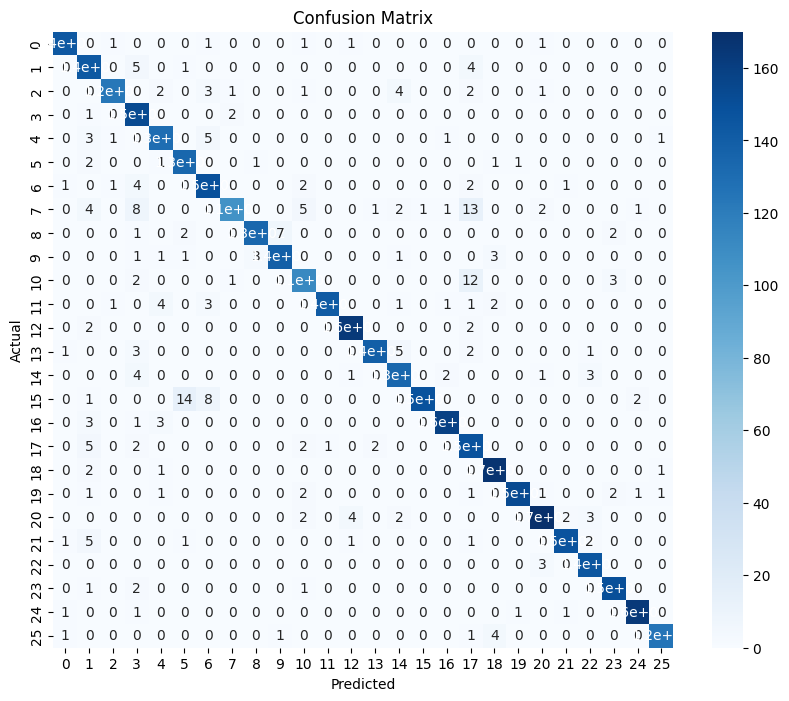

In [8]:
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [9]:
# ROC and AUC (for multiclass use one-vs-rest example)
y_prob = svm_model.predict_proba(X_test)

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score

y_test_bin = label_binarize(y_test, classes=np.unique(y_test))

auc_score = roc_auc_score(y_test_bin, y_prob, multi_class="ovr")
print("AUC Score:", auc_score)

AUC Score: 0.9985024522181364


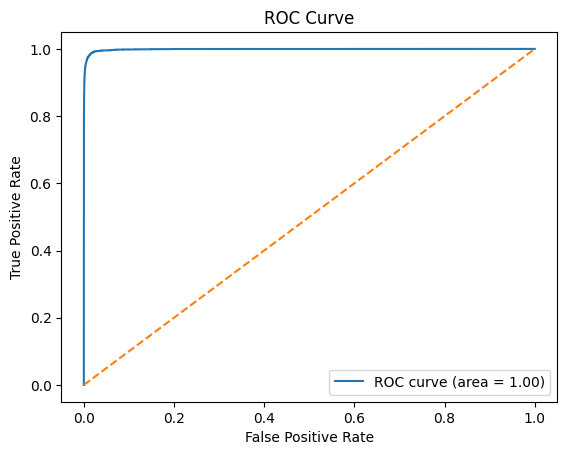

In [10]:
fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_prob.ravel())

roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label="ROC curve (area = %0.2f)" % roc_auc)
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [11]:
# For visualization, let's simplify to a binary classification problem with two features from the Iris dataset.
# We'll use 'petal_length' and 'petal_width' to classify 'setosa' vs 'versicolor'.

# Filter for two species: 'setosa' (0) and 'versicolor' (1)
iris_binary = iris[iris['species'] != 2]
X_binary = iris_binary[['petal_length', 'petal_width']]
y_binary = iris_binary['species']

# Train a linear SVM model on this simplified data
svm_linear_viz = SVC(kernel='linear', C=1.0) # C is the regularization parameter
svm_linear_viz.fit(X_binary, y_binary)

SVC(kernel='linear')

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


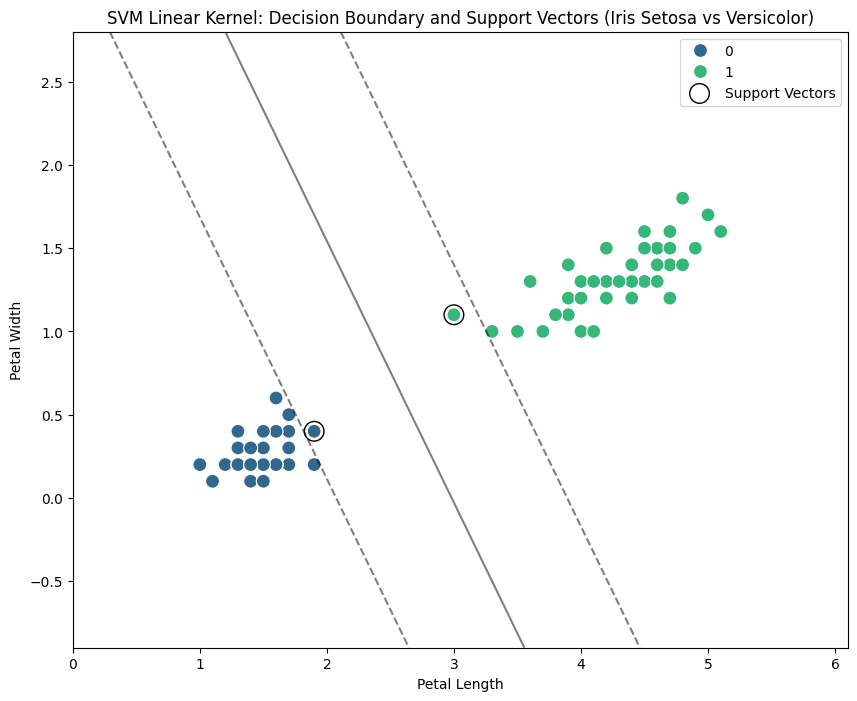

In [12]:
plt.figure(figsize=(10, 8))

# Plot the data points
sns.scatterplot(x='petal_length', y='petal_width', hue='species', data=iris_binary, s=100, palette='viridis', legend='full')

# Plot the decision boundary
ax = plt.gca()
x_min, x_max = X_binary['petal_length'].min() - 1, X_binary['petal_length'].max() + 1
y_min, y_max = X_binary['petal_width'].min() - 1, X_binary['petal_width'].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
Z = svm_linear_viz.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

# Plot decision boundary and margins
ax.contour(xx, yy, Z, colors='k', levels=[-1, 0, 1], alpha=0.5, linestyles=['--', '-', '--'])

# Plot support vectors
ax.scatter(svm_linear_viz.support_vectors_[:, 0],
           svm_linear_viz.support_vectors_[:, 1],
           s=200, facecolors='none', edgecolors='k', label='Support Vectors')

plt.title('SVM Linear Kernel: Decision Boundary and Support Vectors (Iris Setosa vs Versicolor)')
plt.xlabel('Petal Length')
plt.ylabel('Petal Width')
plt.legend()
plt.show()